## Exploratory Data Analysis

## Introduction to the Dataset

The Garment Industry is one of the key examples of the industrial globalization of this modern era. It is a highly labour-intensive industry with lots of manual processes. Satisfying the huge global demand for garment products is mostly dependent on the production and delivery performance of the employees in the garment manufacturing companies. So, it is highly desirable among the decision makers in the garments industry to track, analyse and predict the productivity performance of the working teams in their factories. 

This dataset includes important attributes of the garment manufacturing process and the productivity of the employees which had been collected manually and also been validated by the industry experts.

### Datapoints

1. **Date**- Date in MM-DD-YYYY
2. **Day**- Day of the Week
3. **Department**- Associated department with the instance
4. **Team_no**- Associated team number with the instance
5. **No_of_workers**- Number of workers in each team
6. **No_of_style_change**- Number of changes in the style of a particular product
7. **Targeted_productivity**- Targeted productivity set by the Authority for each team for each day.
8. **Smv**- Standard Minute Value, it is the allocated time for a task
9. **Wip**- Work in progress. Includes the number of unfinished items for products
10. **Over_time**- Represents the amount of overtime by each team in minutes
11. **Incentive**- Represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action
12. **Idle_time**- The amount of time when the production was interrupted due to several reasons
13. **Idle_men**- The number of workers who were idle due to production interruption
14. **Actual_productivity**- The actual % of productivity that was delivered by the workers. It ranges from 0-1.

In [1]:
## Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the dataset as a CSV file
df_garments = pd.read_csv('/kaggle/input/garmentsworkerproductivity/garments_worker_productivity.csv')
df_garments.head()

,date,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,01-01-2015,sewing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,01-01-2015,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,01-01-2015,sewing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,01-01-2015,sewing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,01-01-2015,sewing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


The column names are easily understood and do not require any correction methods to be applied

In [3]:
## List the columns of the dataset
print(df_garments.columns)

Index(['date', 'department', 'day', 'team', 'targeted_productivity', 'smv',
       'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')


## Analysis of the data

### Basic Analysis

* There are 1197 rows in the dataset and 14 columns/features.
* The WIP column has missing values.
* There are three columns that are categorical in nature including the date column. There are eleven columns of numerical datatype, out of which 5 are of integer datatype and 6 are of floating point values
* The date column is of type object, i.e. the data is stored as a string rather than of type datetime

In [4]:
# View the shape of the data
df_garments.shape

(1197, 14)

In [5]:
## Basic analysis of the data - obtain datatypes, non-null count, columns, row count
df_garments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   int64  
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   wip                    691 non-null    float64
 7   over_time              1197 non-null   int64  
 8   incentive              1197 non-null   int64  
 9   idle_time              1197 non-null   float64
 10  idle_men               1197 non-null   int64  
 11  no_of_style_change     1197 non-null   int64  
 12  no_of_workers          1197 non-null   float64
 13  actual_productivity    1197 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 131.0+ 

### Data Transformation

For the purpose of analysis and plotting, it is better to have the column types of the date, department and day column to be changed from object to datetime and string.
1. Change the datatype of date column from object to datetime
2. Change the datatype of department and day columns from object to string

In [6]:
# Change the datatype from object to datetime
df_garments['date'] = pd.to_datetime(df_garments['date'], format='mixed')
df_garments['department'] = df_garments['department'].astype("string")
df_garments['day'] = df_garments['day'].astype("string")
df_garments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1197 non-null   datetime64[ns]
 1   department             1197 non-null   string        
 2   day                    1197 non-null   string        
 3   team                   1197 non-null   int64         
 4   targeted_productivity  1197 non-null   float64       
 5   smv                    1197 non-null   float64       
 6   wip                    691 non-null    float64       
 7   over_time              1197 non-null   int64         
 8   incentive              1197 non-null   int64         
 9   idle_time              1197 non-null   float64       
 10  idle_men               1197 non-null   int64         
 11  no_of_style_change     1197 non-null   int64         
 12  no_of_workers          1197 non-null   float64       
 13  act

### Summarize Null/0 Values

It is observed that only the WIP column has 506 missing values, i.e. 42.27% of the values are missing. Since the WIP column is the number of unfinished items, it can be assumed that there were no unfinished rows for the 506 entries.

In [7]:
## Summarize the missing data
missing_data = df_garments.isnull().sum()
print(missing_data)

date                       0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [8]:
## Get the percentage of missing data
(df_garments.isnull().sum()/(len(df_garments)))*100

date                      0.000000
department                0.000000
day                       0.000000
team                      0.000000
targeted_productivity     0.000000
smv                       0.000000
wip                      42.272348
over_time                 0.000000
incentive                 0.000000
idle_time                 0.000000
idle_men                  0.000000
no_of_style_change        0.000000
no_of_workers             0.000000
actual_productivity       0.000000
dtype: float64

In [9]:
## Obtain the count of 0 values in the columns
zero_counts = (df_garments == 0).sum()
print("Columns and the count of rows with zero entries\n\n", zero_counts)

Columns and the count of rows with zero entries

 date                        0
department                  0
day                         0
team                        0
targeted_productivity       0
smv                         0
wip                         0
over_time                  31
incentive                 604
idle_time                1179
idle_men                 1179
no_of_style_change       1050
no_of_workers               0
actual_productivity         0
dtype: Int64


There are also columns with 0 values as shown above. The overtime column has very less entries with 0 values. Incentive column has 604 entries with 0 values, indicating the entries where incentive was not given.

1179 entries did not have idle time or idle men, indicating that there has been maximum productivity.

There are 1050 entries with 0 value in the no_of_style_change column. It indicates that most products have not undergone any style changes. 

The columns idle_time, idle_men and no_of_style_change can be dropped before further analysis.

In [10]:
## Drop the columns from the df
df_garments.drop(columns=['idle_time', 'idle_men', 'no_of_style_change'], inplace=True)

### Basic Statistical Summary

1. **Team** : The team size ranges from 1 to 12.
2. **Targeted Productivity** : The mean targeted productivity is 0.729, where 0.07 was the lowest and the maximum targeted productivity was 0.8 out of a score between 0 to 1.
3. **SMV (Standard Minute Value)** : It is the minimum time in minutes required to complete a task. From the maximum value of 54.56 minutes, it is understood that there are tasks that require almost an hour to complete. 75% of the values of the column SMV lie below 24.2.
4. **WIP (Work In Progress)** : The number of items unfinished range from 7 to 23122. Most of the values lie below 1252.5 . It is likely that the WIP values may have outliers.
5. **Over Time** : The teams on average have worked for 4567.46 minutes overtime.
6. **Incentive** : Although the maximum incentive is 3600 BDT, the mean incentive is 38.2. There are no values in the 25th or 50th quartile. Out of the 1197 records, 75% of the records have the incentive below 50 BDT.
7. **No. of Workers** - The number of workers in a team range from 2 to 89.
8. **Actual_productivity** - The actual productivity is greater than the targeted predictivity. 75% of the values lie below 0.85 whereas the maximum targeted productivity is 0.8.

The columns WIP, Overtime, and Incentive have small mean values compared to their maximum values. The mean is sensitive to outliers, but the mean value being a small value compared to the maximum value indicates that the maximum value is an outlier.

In [11]:
df1=df_garments.drop(columns=['department', 'day', 'date'])
df1.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,89.000000,1.120437


### Outlier Detection

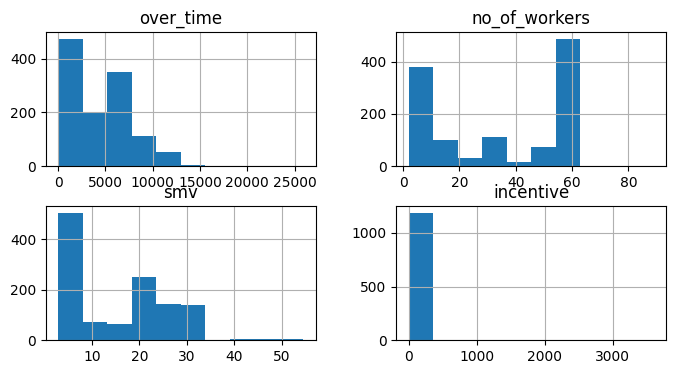

In [12]:
col=['over_time', 'no_of_workers', 'smv' , 'incentive']
df_garments[col].hist(figsize=(8,4))
plt.show()

As the data does not follow a normal distribution, the outlier data points can be calculated using the Interquartile Range (IQR) method. 

**Interquartile Range** : Values lying outside 1.5 times the IQR below the first quartile or above the third quartile are considered outliers and removed from the dataset.

#### Remove Outliers from Incentive Column

Steps to remove the outliers using the IQR method-

1. Calculate the 25th (Q1) and 75th (Q3) percentile of the data.
2. Get the IQR value = Q3-Q1
3. Determine a threshold
4. Remove the values falling below *Q1–1.5*xIQR or above *Q3+1.5*xIQR

In [13]:
q1_incentive = df_garments['incentive'].quantile(0.25)
q3_incentive = df_garments['incentive'].quantile(0.75)
iqr = q3_incentive - q1_incentive
threshold = 1.5
df_garments = df_garments[(df_garments['incentive'] >= q1_incentive - 1.5*iqr) & \
                (df_garments['incentive'] <= q3_incentive + 1.5*iqr)]
df_garments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1186 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1186 non-null   datetime64[ns]
 1   department             1186 non-null   string        
 2   day                    1186 non-null   string        
 3   team                   1186 non-null   int64         
 4   targeted_productivity  1186 non-null   float64       
 5   smv                    1186 non-null   float64       
 6   wip                    690 non-null    float64       
 7   over_time              1186 non-null   int64         
 8   incentive              1186 non-null   int64         
 9   no_of_workers          1186 non-null   float64       
 10  actual_productivity    1186 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), string(2)
memory usage: 111.2 KB


In [14]:
# Remove outliers from overtime column
q1_overtime = df_garments['over_time'].quantile(0.25)
q3_overtime = df_garments['over_time'].quantile(0.75)
iqr = q3_overtime - q1_overtime
threshold = 1.5
print(q1_overtime, q3_overtime, iqr)
df_garments = df_garments[(df_garments['over_time'] >= q1_overtime - 1.5*iqr) & \
                (df_garments['over_time'] <= q3_overtime + 1.5*iqr)]
df_garments.info()

1440.0 6960.0 5520.0
<class 'pandas.core.frame.DataFrame'>
Index: 1185 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1185 non-null   datetime64[ns]
 1   department             1185 non-null   string        
 2   day                    1185 non-null   string        
 3   team                   1185 non-null   int64         
 4   targeted_productivity  1185 non-null   float64       
 5   smv                    1185 non-null   float64       
 6   wip                    689 non-null    float64       
 7   over_time              1185 non-null   int64         
 8   incentive              1185 non-null   int64         
 9   no_of_workers          1185 non-null   float64       
 10  actual_productivity    1185 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), string(2)
memory usage: 111.1 KB


In [15]:
# Remove outliers from smv column
q1_smv = df_garments['smv'].quantile(0.25)
q3_smv = df_garments['smv'].quantile(0.75)
iqr = q3_smv - q1_smv
threshold = 1.5
print(q1_smv, q3_smv, iqr)
df_garments = df_garments[(df_garments['smv'] >= q1_smv - 1.5*iqr) & \
                (df_garments['smv'] <= q3_smv + 1.5*iqr)]
df_garments.info()

3.94 24.26 20.32
<class 'pandas.core.frame.DataFrame'>
Index: 1185 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1185 non-null   datetime64[ns]
 1   department             1185 non-null   string        
 2   day                    1185 non-null   string        
 3   team                   1185 non-null   int64         
 4   targeted_productivity  1185 non-null   float64       
 5   smv                    1185 non-null   float64       
 6   wip                    689 non-null    float64       
 7   over_time              1185 non-null   int64         
 8   incentive              1185 non-null   int64         
 9   no_of_workers          1185 non-null   float64       
 10  actual_productivity    1185 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), string(2)
memory usage: 111.1 KB


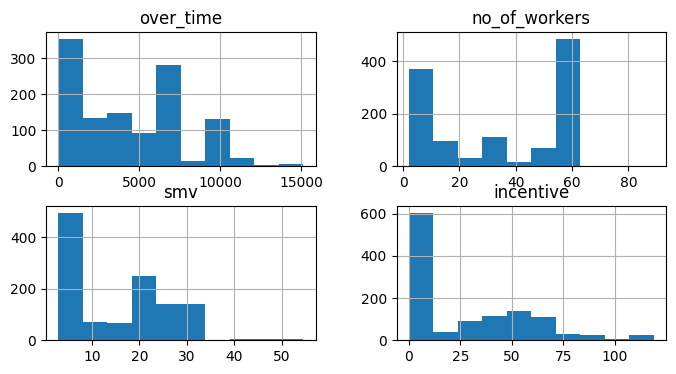

In [16]:
## Plot after removing the outliers in incentive and overtime column
col=['over_time', 'no_of_workers', 'smv' , 'incentive']
df_garments[col].hist(figsize=(8,4))
plt.show()

In [17]:
df1=df_garments.drop(columns=['department', 'day', 'date'])
df1.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,no_of_workers,actual_productivity
count,1185.000000,1185.000000,1185.000000,689.000000,1185.000000,1185.000000,1185.000000,1185.000000
mean,6.427004,0.729890,15.153468,1191.477504,4591.839662,25.790717,34.783966,0.735085
std,3.457993,0.097566,10.946388,1839.784253,3278.535169,30.259437,22.174669,0.173699
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,776.000000,1440.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,4080.000000,0.000000,34.000000,0.771583
75%,9.000000,0.800000,24.260000,1251.000000,6960.000000,50.000000,57.000000,0.850224
max,12.000000,0.800000,54.560000,23122.000000,15120.000000,119.000000,89.000000,1.120437


It is observed that after removing the outliers in the overtime, smv and incentive columns, the distribution of the data in these columns have become more tighter disribution of data. The mean value of the incentive column has varied considerably.

## Distribution of Data

### Total records per department, day and team

* Majority records are from the sewing department.
* The working days are through Sunday to Saturday with the exception of Friday
* There are 12 different teams whose data has been recorded

In [18]:
# Get unique values of the column as a list
unique_departments = df_garments['department'].unique()
unique_days = df_garments['day'].unique()

print("Unique Departments- \n", unique_departments)
print("\nUnique Days- \n", unique_days)

Unique Departments- 
 <StringArray>
['sewing', 'finishing']
Length: 2, dtype: string

Unique Days- 
 <StringArray>
['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 6, dtype: string


In [19]:
# Get total records of unique departments
unique_dept_count = df_garments['department'].value_counts()
print("Total records per department - \n\n", unique_dept_count)
df_unique_dept = unique_dept_count.reset_index()
df_unique_dept.columns = ['department', 'count'] 

Total records per department - 

 department
sewing       689
finishing    496
Name: count, dtype: Int64


In [20]:
# Get total records of unique days
unique_days_count = df_garments['day'].value_counts()
print("Total records per day - \n\n", unique_days_count)
df_unique_days = unique_days_count.reset_index()
df_unique_days.columns = ['day', 'count'] 

# Sorting the days of the week to ensure the correct order 
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Saturday', 'Sunday']
df_unique_days['day'] = pd.Categorical(df_unique_days['day'], categories=days_order, ordered=True)
df_unique_days = df_unique_days.sort_values('day')

Total records per day - 

 day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     197
Monday       189
Saturday     187
Name: count, dtype: Int64


In [21]:
# Get total number of teams working
unique_team_count = df_garments['team'].value_counts()
print("Total records per team - \n\n", unique_team_count)

df_unique_team_count = unique_team_count.reset_index()
df_unique_team_count.columns = ['team', 'count'] 

# Sort the df by 'team_number'
df_unique_team_count = df_unique_team_count.sort_values(by='team')

Total records per team - 

 team
8     108
2     108
4     104
1     103
9     103
10     99
12     98
7      96
6      94
3      94
5      92
11     86
Name: count, dtype: int64


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


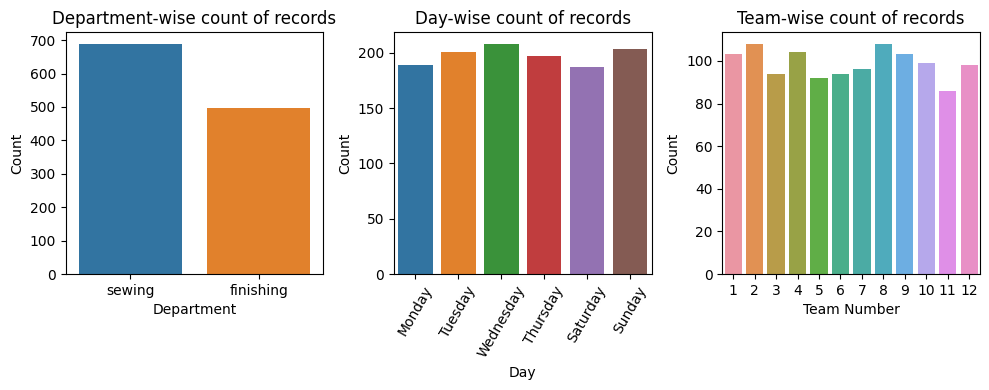

In [22]:
## Plot using subplot
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

## Department-wise count of records
sns.barplot(ax=axes[0], x='department', y='count', data=df_unique_dept)
axes[0].set_title('Department-wise count of records')  
axes[0].set_xlabel('Department') 
axes[0].set_ylabel('Count') 

## Day-wise count of records
sns.barplot(ax=axes[1], x='day', y='count', data=df_unique_days)
axes[1].set_title('Day-wise count of records')  
axes[1].set_xlabel('Day')  
axes[1].set_xticklabels(df_unique_days['day'], rotation=60) 
axes[1].set_ylabel('Count')  

## Team-wise count of records
sns.barplot(ax=axes[2], x='team', y='count', data=df_unique_team_count)
axes[2].set_title('Team-wise count of records')  
axes[2].set_xlabel('Team Number')  
axes[2].set_ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.show()

The data across all three plots are well distributed.

It is seen from the day-wise count of records that the working days are all the days except Friday. The data is also well represented across all the days. The maximum records seem to be for Wednesday and the minimum records seem to be available for Monday.

From the team-wise count of the records, each team is also well represented. Team number 2 and 8 seem to have the maximum data and team number 11 has the minimum data.

#### Average Workers by Team and Department

On an average, there are 10 members per team in the finishing department and 52 members per team in the sewing department

In [23]:
# Group the data by 'department'
department_summary = df_garments.groupby('department').agg({
    'no_of_workers': 'mean',   # Mean of workers per department
    'team': 'nunique'         # Count unique teams per department
}).reset_index()

# Rename the columns for clarity
department_summary.rename(columns={'no_of_workers': 'avg_workers_per_team', 'team': 'total_teams'}, inplace=True)

# Display the summary
print(department_summary)

  department  avg_workers_per_team  total_teams
0  finishing             10.262097           12
1     sewing             52.436865           12


## Productivity Analysis - Actual vs Targeted Productivity

### Time series analysis of actual vs targeted productivity

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

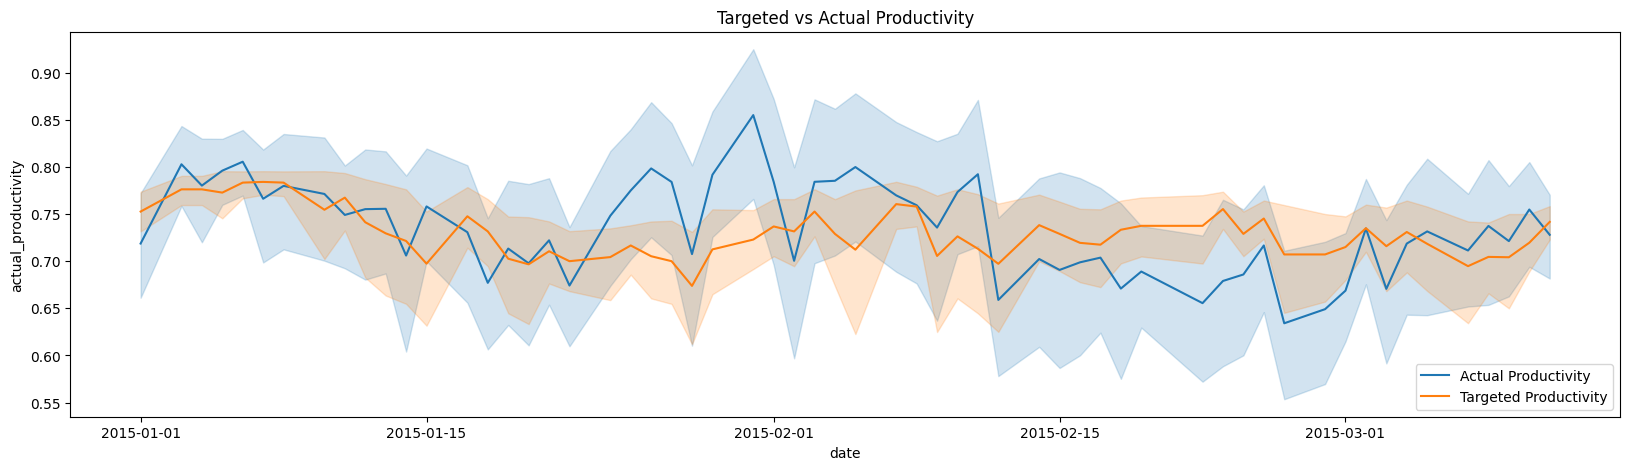

In [24]:
# Line plot of Date vs Productivity
fig = plt.subplots(figsize=(20, 5))
sns.lineplot(data=df_garments,x='date', y='actual_productivity', label='Actual Productivity')
sns.lineplot(data=df_garments,x='date', y='targeted_productivity', label='Targeted Productivity')
plt.title('Targeted vs Actual Productivity')
plt.legend(loc='lower right')
plt.show()

During the first two weeks of Jan 2015, the productivity alternates between meeting the target and failing to meet the target.

It is observed from the graph below that from the mid of Jan 2015 to the mid of Feb 2015, the actual productivity has mostly exceeded the target.

From the mid of Feb 2015 to the first week of March 2015, there is a considerable drop in the productivity.

### Time series analysis of actual vs targeted productivity based on departments

#### Productivity Analysis of Sewing Department

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

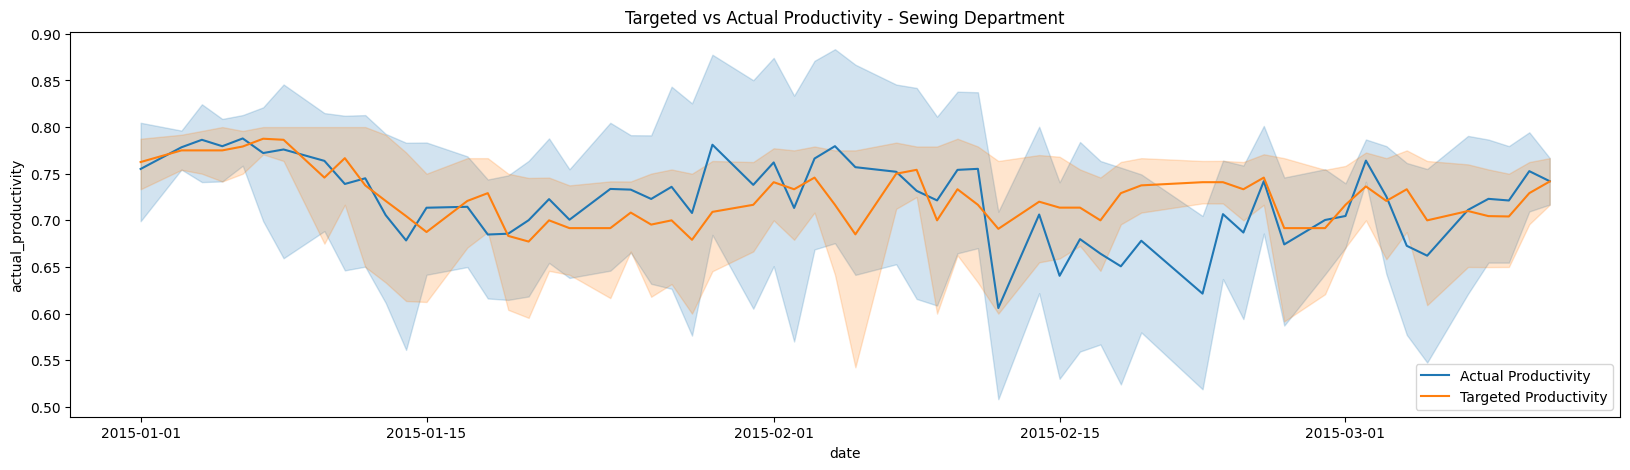

In [25]:
# Line plot of department vs productivity
df_sewing = df_garments[df_garments['department']=='sewing']
df_finishing = df_garments[df_garments['department']=='finishing']
fig,axes = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_sewing,x='date', y='actual_productivity', label='Actual Productivity')
sns.lineplot(data=df_sewing,x='date', y='targeted_productivity', label='Targeted Productivity')
plt.title('Targeted vs Actual Productivity - Sewing Department')
plt.legend(loc='lower right')
plt.show()

#### Productivity Analysis of Finishing Department

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

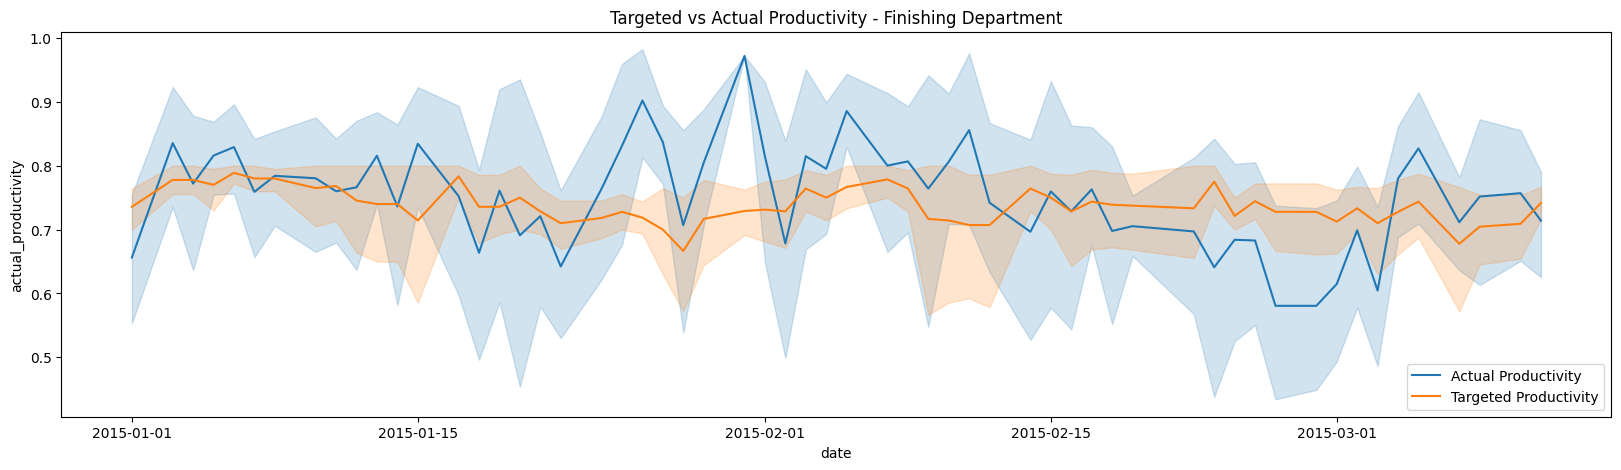

In [26]:
# Line plot of department vs productivity
df_finishing = df_garments[df_garments['department']=='finishing']
fig,axes = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_finishing,x='date', y='actual_productivity', label='Actual Productivity')
sns.lineplot(data=df_finishing,x='date', y='targeted_productivity', label='Targeted Productivity')
plt.title('Targeted vs Actual Productivity - Finishing Department')
plt.legend(loc='lower right')
plt.show()

The productivity of the indivual departments also correspond to the total productivity across both the departments. Although the spike in productivity seen was due to the productivity increase in the finishing department.

### Productivity based on days

In [27]:
## Analysing productivity based on days
# Group the data by 'day' and calculate the mean of actual and targeted productivity
productivity_by_day = df_garments.groupby('day').agg({
    'actual_productivity': 'mean',
    'targeted_productivity': 'mean'
}).reset_index()

# Sorting the days of the week to ensure the correct order 
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Saturday', 'Sunday']
productivity_by_day['day'] = pd.Categorical(productivity_by_day['day'], categories=days_order, ordered=True)
productivity_by_day = productivity_by_day.sort_values('day')

productivity_by_day

,day,actual_productivity,targeted_productivity
0,Monday,0.735365,0.729365
4,Tuesday,0.742701,0.727612
5,Wednesday,0.730462,0.729087
3,Thursday,0.722615,0.722183
1,Saturday,0.751929,0.733690
2,Sunday,0.728604,0.737438


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

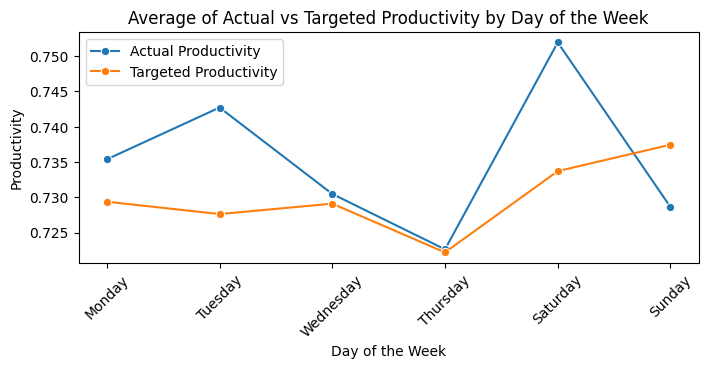

In [28]:
# Plot actual vs targeted productivity by day of the week
plt.figure(figsize=(8, 3))
sns.lineplot(x='day', y='actual_productivity', data=productivity_by_day, marker='o', label='Actual Productivity')
sns.lineplot(x='day', y='targeted_productivity', data=productivity_by_day, marker='o', label='Targeted Productivity')

plt.title('Average of Actual vs Targeted Productivity by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Productivity')
plt.xticks(rotation=45)
plt.legend()

From the plot of the day-wise average of actual and targeted productivity by day of the week, it is observed that on all working days except Sunday, the targets have been met and even exceeded considerably on Tuesdays and Saturdays.

## Team-wise Analysis of Overtime, SMV (Standard Minute Value) and Incentive

In [29]:
# Group the data by 'team' and calculate the mean of over time and incentive
team_data = df_garments.groupby('team').agg({
    'over_time': 'mean',
    'incentive': 'mean',
    'smv': 'mean',
    'no_of_workers': 'mean',
    'actual_productivity':'mean',
    'targeted_productivity':'mean'
}).reset_index()

team_data.head()

,team,over_time,incentive,smv,no_of_workers,actual_productivity,targeted_productivity
0,1,4886.504854,36.844660,15.412427,35.092233,0.818599,0.746117
1,2,4425.555556,27.453704,14.740185,34.851852,0.771673,0.740278
2,3,5432.872340,34.765957,17.452021,39.813830,0.803970,0.741489
3,4,5502.115385,26.153846,17.030000,38.490385,0.769791,0.717308
4,5,5388.913043,18.369565,18.375870,39.679348,0.696173,0.674457


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

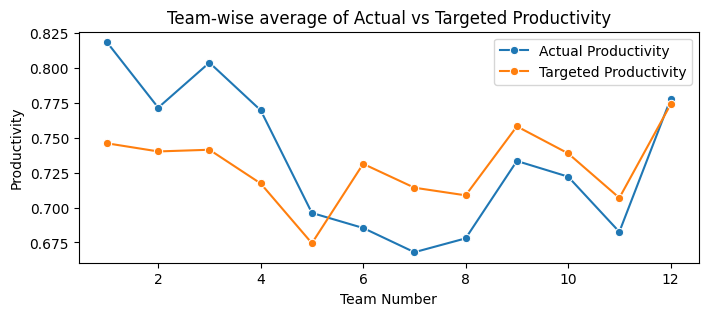

In [30]:
# Plot actual vs targeted productivity by team
plt.figure(figsize=(8, 3))
sns.lineplot(x='team', y='actual_productivity', data=team_data, marker='o', label='Actual Productivity')
sns.lineplot(x='team', y='targeted_productivity', data=team_data, marker='o', label='Targeted Productivity')

plt.title('Team-wise average of Actual vs Targeted Productivity')
plt.xlabel('Team Number')
plt.ylabel('Productivity')
plt.legend()

From the team-wise plot of actual vs targeted productivity, it is noted that the teams 1 to 5 and team 12 have exceeded their targets, but teams 6 to 11 have not met the targeted productivity. 

Normalization of the data, wherein all features would be brought to a similar scale, allows for a more accurate assessment of their relationships.

### Normalization

The Min-Max Scaler is a normalization technique that transforms features to a fixed range, usually between 0 and 1. This is particularly useful when the relationships between values have to be maintained while ensuring they are on the same scale.

The formula for Min-Max scaling is: 
                        X' = (X- Xmin) / (Xmax - Xmin)

where -
 
* X is the original value
* X' is the normalized value
* Xmin is the minimum value of the feature
* Xmax is the maximum value of the feature

### Normalization of team-wise data

In [31]:
## Normalize values to display relationship between teams and overtime, incentive, no of workers and productivity
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

df_team_normalized = team_data
# Fit and transform the data (excluding the team)
df_team_normalized[['over_time', 'incentive', 'smv', 'no_of_workers', 'actual_productivity']] = scaler.fit_transform(team_data[['over_time', 'incentive', 'smv', 'no_of_workers', 'actual_productivity']])

df_team_normalized.head()

,team,over_time,incentive,smv,no_of_workers,actual_productivity,targeted_productivity
0,1,0.713713,1.000000,0.616183,0.700071,1.000000,0.746117
1,2,0.499351,0.559387,0.529116,0.684802,0.688396,0.740278
2,3,0.967799,0.902470,0.880346,1.000000,0.902859,0.741489
3,4,1.000000,0.498400,0.825687,0.915931,0.675898,0.717308
4,5,0.947356,0.133170,1.000000,0.991457,0.187040,0.674457


### Team-wise comparison of overtime, incentive and SMV

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

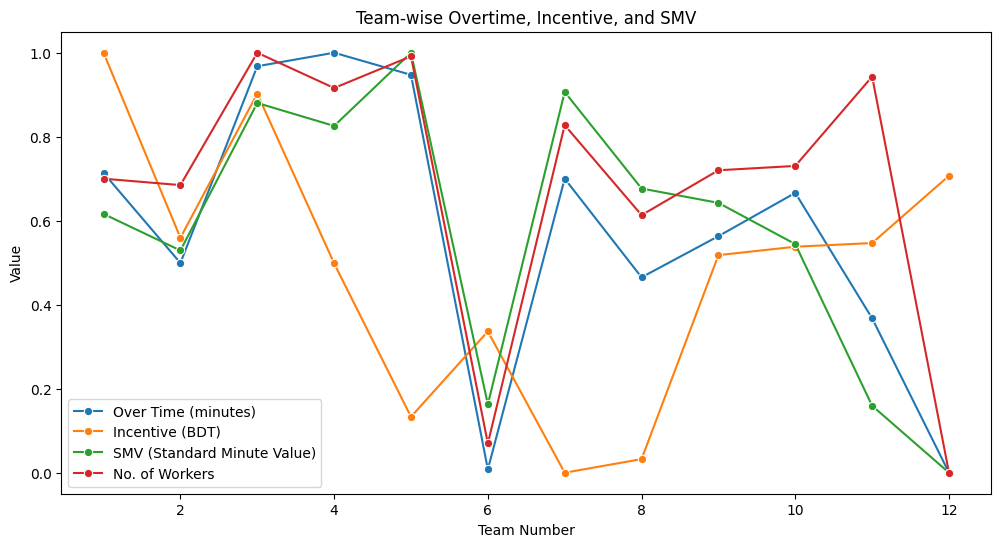

In [32]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Plot over_time, incentive, and smv on the y-axis against the team number
sns.lineplot(x='team', y='over_time', data=df_team_normalized, label='Over Time (minutes)', marker='o')
sns.lineplot(x='team', y='incentive', data=df_team_normalized, label='Incentive (BDT)', marker='o')
sns.lineplot(x='team', y='smv', data=df_team_normalized, label='SMV (Standard Minute Value)', marker='o')
sns.lineplot(x='team', y='no_of_workers', data=df_team_normalized, label='No. of Workers', marker='o')

# Customize the plot
plt.title('Team-wise Overtime, Incentive, and SMV')
plt.xlabel('Team Number')
plt.ylabel('Value')
plt.legend()

The team-wise plot to compare overtime, incentive and SMV using the normalized data indicates that overtime and SMV are almost always closely related with each other. Even though team 12 has the least number of workers, SMV and overtime, their incentive is very high.
Teams 5 and 7 have had the work with the most SMV, but their gain in incentive is lower.
Though teams 1and 6 have had less overtime, no of workers and SMV, their incentive is on the higher side.


## Feature Correlation

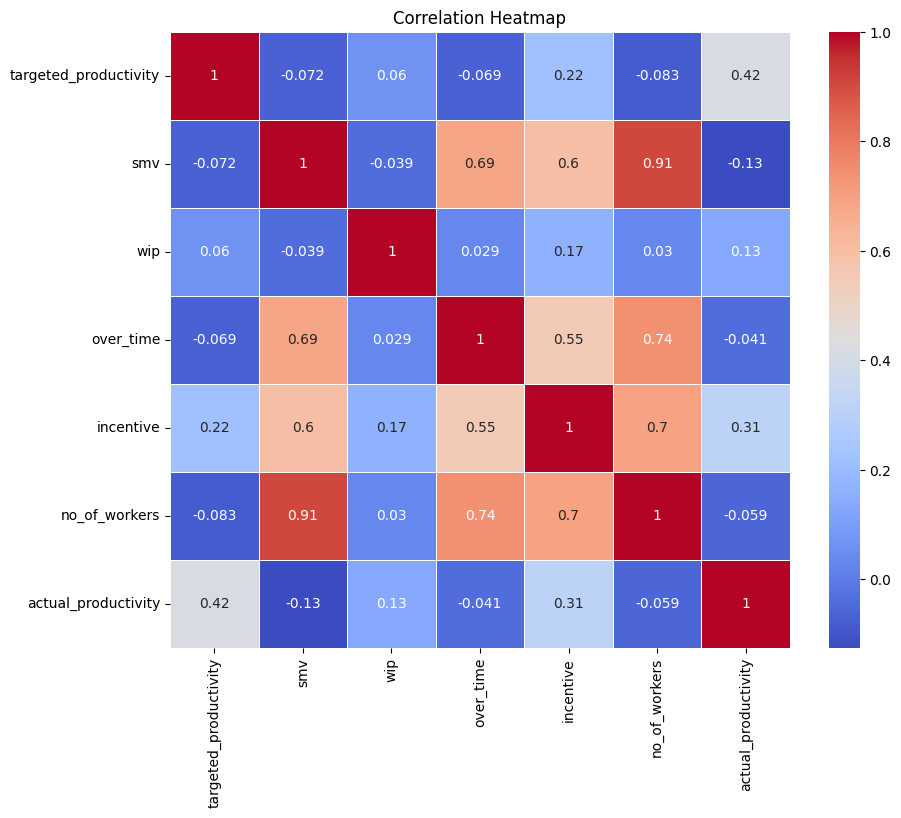

In [33]:
# Correlation heatmap for the numeric columns to understand relationships
df1 = df_garments.drop(columns=['department', 'day', 'date', 'team'])
plt.figure(figsize=(10, 8))
corr_matrix = df1.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

1. The correlation value closer to 1 indicates strong positive correlationship.
2. The value closer to -1 indicates strong negative correlationship.
3. Correlation value closer to 0 indicates no correlation between the values.

There are notable positive correlations between SMV, No. of Workers, Incentive and Overtime and no considerable negative correlation between the features.

The strong correlation between the number of workers and SMV suggests that as the SMV increases, the number of workers require to meet the demands should also increase. If increasing the workforce leads to higher SMV and Overtime, it may necessitate an evaluation of task allocation and efficiency. It could indicate that even with a larger workforce, there may be increased demand for labor hours to meet task completion goals, especially if SMV is high. If tasks are taking longer (higher SMV), it may lead to increased overtime, which could raise costs. 

Higher Standard Minute Value (SMV) may also lead to greater incentives for workers. The correlations with incentives suggest that modifying the incentive structure might help improve productivity, especially in tasks with higher SMV. 

##### The major features to consider include Overtime, SMV, Incentive, No. of Workers and Actual Productivity

Features like over_time (ranging from 0 to 15120), SMV (ranging from 2.9 to 54.56), actual productivity (ranging from 0.23 to 1.12), no. of workers (ranging from 2 to 89) and incentive (ranging from 0 to 119) have significantly different ranges. This difference in scale can distort the relationship between features and the target variable, i.e. actual productivity, when calculating correlation. 

Features with larger ranges may dominate the correlation metrics.

### Pair-Plot on Normalized Data

* A pair plot displays scatterplots for every combination of two variables in the dataset. Each subplot shows how one variable relates to another, helping identify correlations and patterns.
* On the diagonal, the pair plot displays histograms or kernel density estimates (KDE) for each individual variable.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

<Figure size 1000x700 with 0 Axes>

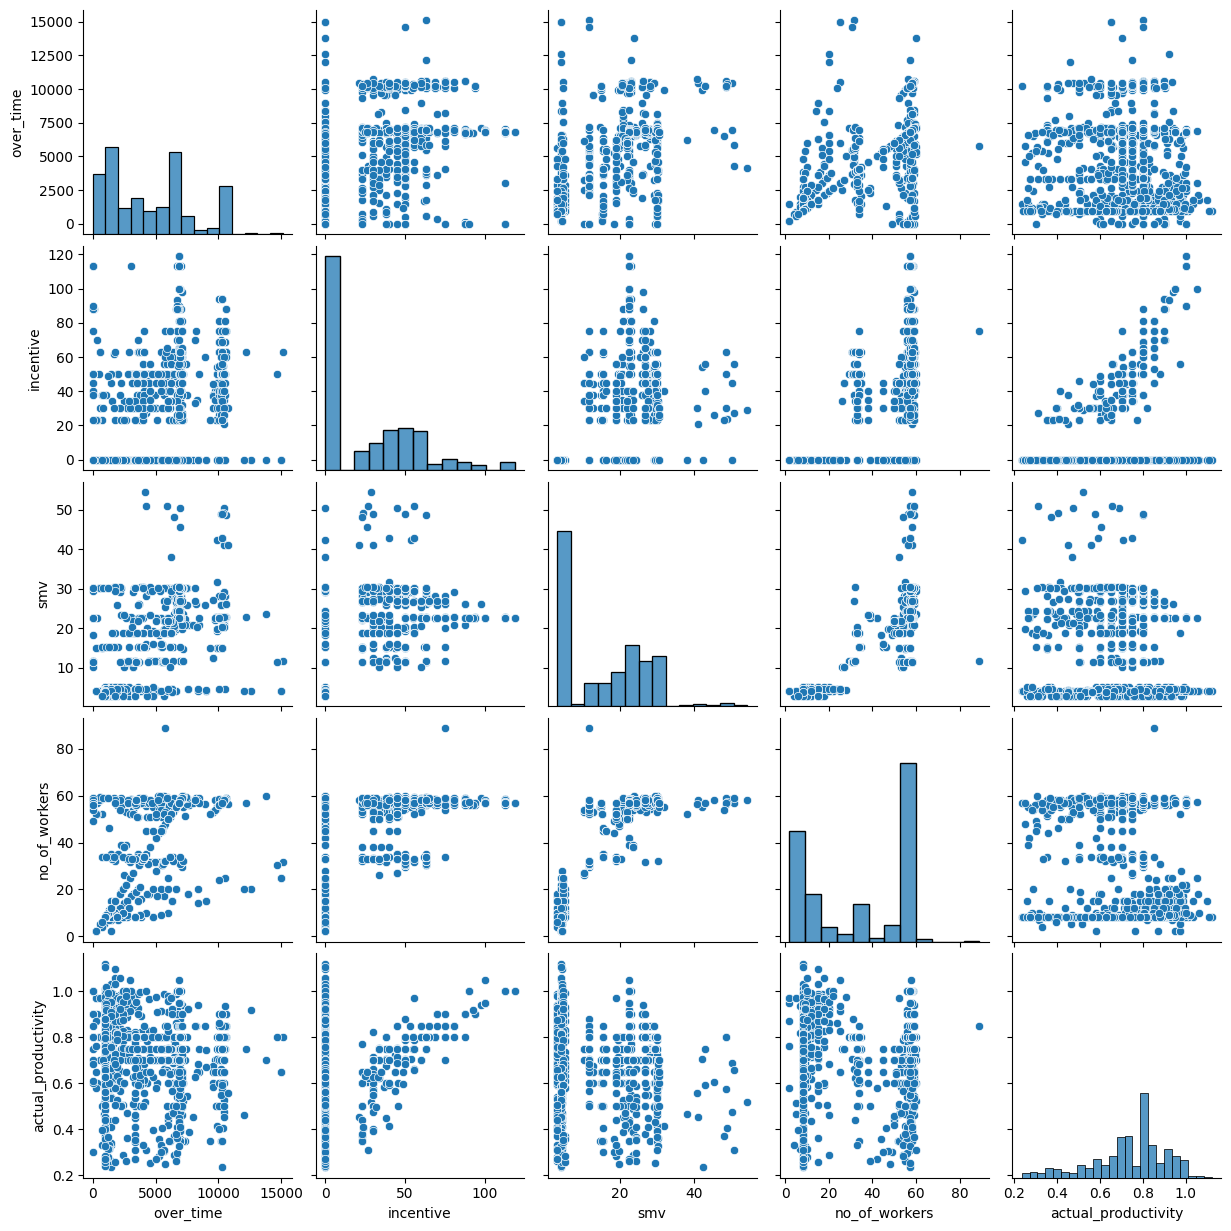

In [34]:
fig = plt.figure(figsize=(10, 7))
sns.pairplot(df_garments[['over_time', 'incentive', 'smv', 'no_of_workers', 'actual_productivity']])
plt.show()

The pair plot shows that the actual productivity is slightly skewed to the left, indicating that there are some outliers, the overtime, SMV and incentive are skewed to the right (peak of the distribution (mode) is located to the left of the mean). The correlations between the features mentioned above have become more evident with the visualization of the scatter plots between the features.

## Regression

### Simple Linear Regression

#### Prediction of Overtime based on No. of Workers

The number of workers is the independent variable and overtime is the dependent variable. This can help in making data-driven decisions about workforce management, labor costs, and productivity.

As the correlation suggests strong positive relationship between the variables, regression is used for the prediction.

In [35]:
# Import the necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
X = df_garments[['no_of_workers']]  # Feature matrix
y = df_garments['over_time']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

# Initialize the MinMaxScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit and transform the feature matrix (X)
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Fit and transform the target variable (y)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Create and fit the model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

#Predict and evaluate the model
y_pred_scaled = model.predict(X_test_scaled)

# Invert the normalization for the target variable
y_pred = scaler_y.inverse_transform(y_pred_scaled)

In [37]:
import math 

# Evaluate the model 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Mean Squared Error: {mse:.4f}")
print(f"R square Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Squared Error: 5456095.9992
R square Score: 0.5064
Root Mean Squared Error (RMSE): 2335.8288


#### Model Evaluation
**Mean Squared Error** - The Mean Squared Error quantifies the average squared difference between the predicted and actual values. A higher MSE indicates that the model's predictions are farther from the actual values. 

The relatively high MSE, suggests that the model may not be accurately capturing the relationship between the number of workers and the overtime. This could imply that there are other significant factors influencing overtime hours that are not included in the model.

**R square score** - It tells the proportion of variance in the dependent variable that can be explained by the independent variable. An R-squared close to 1 suggests a strong relationship. 

As the value of R square is around 0.5, it suggests a moderate correlation. There may also be some other factors in determining the relationship.

**Root Mean Squared Error (RMSE)** - The RMSE provides a measure of the average magnitude of the prediction errors, expressed in the same units as the target variable. 

The high RMSE value suggests that the model's predictions deviate from the actual overtime by the given RMSE value. The high deviation is not desirable. Hence the model's prediction accuracy is limited.

#### Prediction

In [38]:
## Predict New Values
new_data = pd.DataFrame({'no_of_workers': [23, 46, 14, 56]}) 

# Make predictions
predictions = model.predict(new_data)

# Display the predictions
for i, workers in enumerate(new_data['no_of_workers']):
    print(f"Predicted Overtime for {workers} workers : {predictions[i][0]:.4f} minutes")


Predicted Overtime for 23 workers : 14.6544 minutes
Predicted Overtime for 46 workers : 29.2445 minutes
Predicted Overtime for 14 workers : 8.9452 minutes
Predicted Overtime for 56 workers : 35.5881 minutes


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


### Multiple Linear Regression

#### Prediction of Overtime based on no. of workers, SMV and incentives

In [39]:
X_mul = df_garments[['smv', 'no_of_workers', 'incentive']]
y_mul = df_garments[['over_time']]  # Target variable

In [40]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_mul, y_mul, test_size=0.2, random_state=25)

# Initialize the MinMaxScaler
scaler_mul = MinMaxScaler()

##scale overtime
scaler_overtime = MinMaxScaler()

## Select only the considered features
X_train_scaled = scaler_mul.fit_transform(X_train)
X_test_scaled = scaler_mul.fit_transform(X_test)

## Select only the considered features
y_train_scaled = scaler_overtime.fit_transform(y_train)
y_test_scaled = scaler_overtime.fit_transform(y_test)

#Fit the regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

#Predict and evaluate the model
y_pred_scaled = model.predict(X_test_scaled)

#Invert the normalized values
y_pred = scaler_overtime.inverse_transform(y_pred_scaled)

#### Model Evaluation

In [41]:
import math 

# Evaluate the model 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Squared Error: 8895721.0273
R² Score: 0.1092
Root Mean Squared Error (RMSE): 2982.5695


The R square value is close to 0 which suggests that the prediction results are not great. The mean squared error and the root mean squared error values are also very high, which suggests that the multiple linear regression model is not suitable for predicting the overtime values.

#### Prediction

In [42]:
# Making predictions with new values
new_values = pd.DataFrame({
    'smv': [13, 15],  
    'no_of_workers': [65,37],
    'incentive': [60, 86], 
    # 'targeted_productivity': [0.67, 0.67],  
})

# Normalize new values using the same scaler
new_values_normalized = scaler_mul.transform(new_values)

# Predict using the trained model
predictions = model.predict(new_values_normalized)

# Display predictions
predicted_overtime = scaler_overtime.inverse_transform(predictions)

print("Predictions for new values:")
for idx, pred in enumerate(predictions):
    print(f"\nPrediction of Overtime for \n {new_values[idx:idx+1]} \n Overtime = {pred[0]:.4f}")

Predictions for new values:

Prediction of Overtime for 
    smv  no_of_workers  incentive
0   13             65         60 
 Overtime = 0.3773

Prediction of Overtime for 
    smv  no_of_workers  incentive
1   15             37         86 
 Overtime = 0.2655
